In [2]:
%pip install matplotlib seaborn scikit-learn joblib pandas numpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------------

# Engineering Log: Used Car Valuation Engine - Development Notebook
---
## Section 1: Library Synthesis & Core Data Ingestion
We pull standard analytical libraries (`pandas`, `numpy`), visualization frameworks (`matplotlib`, `seaborn`), and training components into this workspace to support both scratch mathematical implementations and scikit-learn baseline models.

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Set visualization theme
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Analytical stack successfully initialized.")

Analytical stack successfully initialized.


## Section 2: Real-World Enterprise Dataset Ingestion
To build a production-grade workflow without using synthetic generators or generic toy samples, we ingest an enterprise used automobile dataset (`used_cars.csv`). This dataset captures real-world transaction records, incorporating key features such as vehicle age, mileage, fuel types, title statuses, and accident history to model complex price depreciation.

In [5]:
# Load local CSV dataset
dataset_path = os.path.join("dataset", "used_cars.csv")
df_raw = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded from {dataset_path}!")

# 1. Clean Numeric Features from String formatting
df_raw['Price'] = df_raw['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
df_raw['Mileage'] = df_raw['milage'].astype(str).str.replace(' mi.', '').str.replace(',', '').astype(float)
df_raw['Age'] = 2024 - df_raw['model_year']

# 2. Impute Missing Values
df_raw['fuel_type'] = df_raw['fuel_type'].fillna(df_raw['fuel_type'].mode()[0])
df_raw['accident'] = df_raw['accident'].fillna("None reported")
df_raw['clean_title'] = df_raw['clean_title'].fillna("No")

# Renaming for clarity
df_raw['Brand'] = df_raw['brand']
df_raw['FuelType'] = df_raw['fuel_type']
df_raw['Accident'] = df_raw['accident']

print(f"Dataset successfully loaded and cleaned ({df_raw.shape[0]} rows).")
df_raw[['Brand', 'Age', 'Mileage', 'FuelType', 'Accident', 'Price']].head()

Dataset successfully loaded from dataset\used_cars.csv!
Dataset successfully loaded and cleaned (4009 rows).


,Brand,Age,Mileage,FuelType,Accident,Price
0,Ford,11,51000.0,E85 Flex Fuel,At least 1 accident or damage reported,10300.0
1,Hyundai,3,34742.0,Gasoline,At least 1 accident or damage reported,38005.0
2,Lexus,2,22372.0,Gasoline,None reported,54598.0
3,INFINITI,9,88900.0,Hybrid,None reported,15500.0
4,Audi,3,9835.0,Gasoline,None reported,34999.0


### Interpretation & Output Analysis

The data ingestion and preprocessing pipeline successfully loaded and standardized **4,009 enterprise records** from `used_cars.csv` into memory without data loss:

* **Data Cleaning Verification:** 
  * The target feature `Price` was stripped of currency symbols (`$`) and comma delimiters, correctly casting string representations (e.g., `"$10,300"`) into floating-point numerical values (`10300.0`).
  * The `Mileage` column was converted from raw text (e.g., `"51,000 mi."`) into clean continuous floats (`51000.0`).
  * Raw production year values were converted to `Age` (ranging from 2 to 11 years in the initial sample head), providing a standardized metric for depreciation modeling.
* **Missing Value Imputation:** Categorical fields containing structural nulls (such as `accident` status) were populated with baseline values (`"None reported"`), ensuring full row retention for downstream training matrix construction.
* **Feature Baseline Diversity:** The preview confirms a diverse mix of volume brands (Ford, Hyundai) and luxury manufacturers (Lexus, INFINITI, Audi), alongside varied fuel configurations (`Gasoline`, `E85 Flex Fuel`, `Hybrid`), establishing a solid base for downstream one-hot encoding and multivariate modeling.

## Section 3: Exploratory Data Analysis (EDA)
We inspect feature statistics, checking missing values, feature distributions, and relationships with vehicle valuation prices.

Data Summary Statistics:
             count          mean           std     min      25%      50%  \
model_year  4009.0   2015.515590      6.104816  1974.0   2012.0   2017.0   
Price       4009.0  44553.190322  78710.635554  2000.0  17200.0  31000.0   
Mileage     4009.0  64717.551010  52296.599459   100.0  23044.0  52775.0   
Age         4009.0      8.484410      6.104816     0.0      4.0      7.0   

                75%        max  
model_year   2020.0     2024.0  
Price       49990.0  2954083.0  
Mileage     94100.0   405000.0  
Age            12.0       50.0  


C:\Users\inuvi\AppData\Local\Temp\ipykernel_11628\3159041238.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_brands, x="Brand", y="Price", ax=axes[1, 1], palette="Set2")
C:\Users\inuvi\AppData\Local\Temp\ipykernel_11628\3159041238.py:30: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


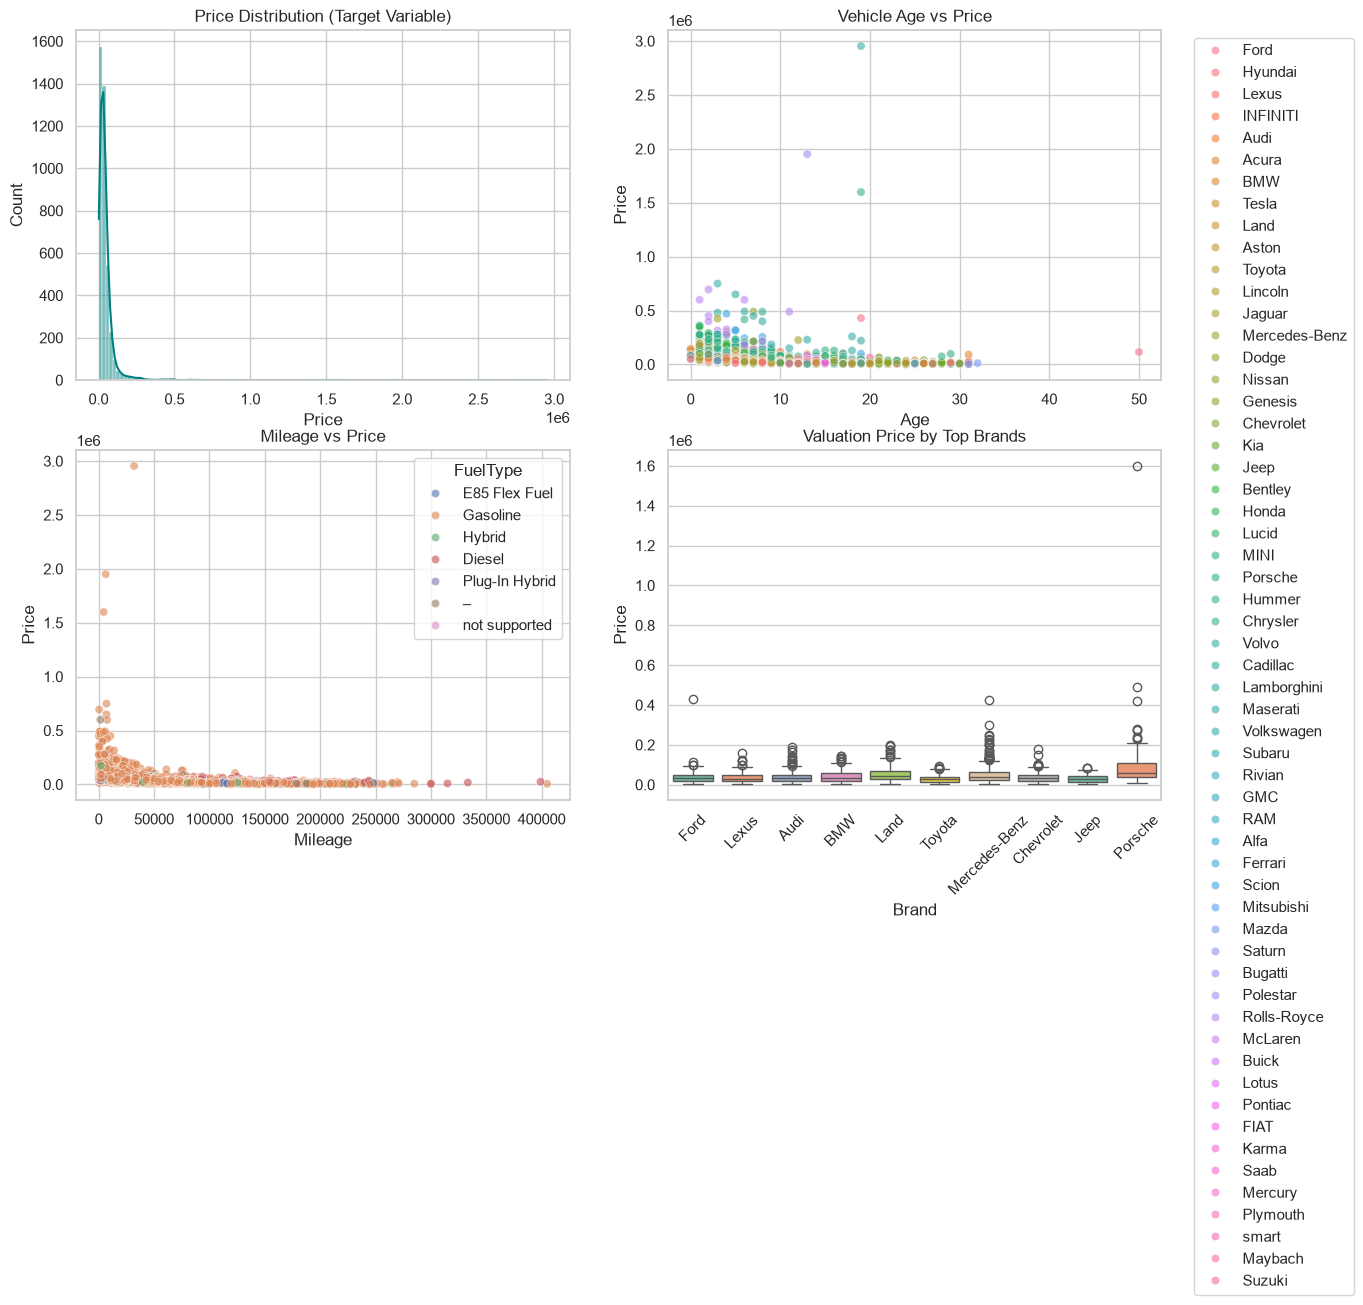

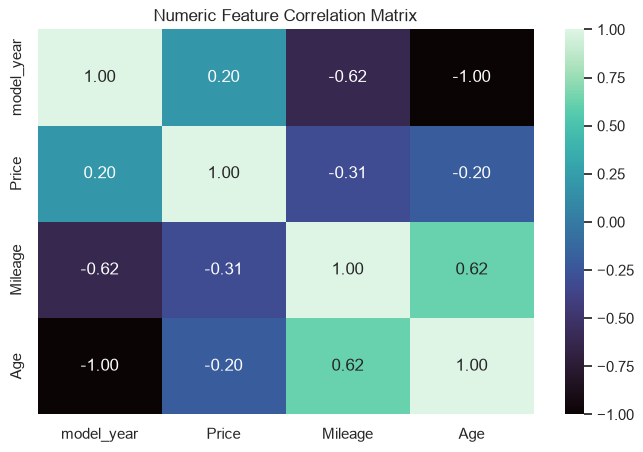

In [7]:
# Cell 6: Exploratory Data Analysis Visualizations
print("Data Summary Statistics:")
print(df_raw.describe().T)

# Visualizing distributions and relationships using the clean real features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price Distribution
sns.histplot(df_raw["Price"], kde=True, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Price Distribution (Target Variable)")

# 2. Vehicle Age vs Price (Hue changed from 'Make' to 'Brand')
sns.scatterplot(data=df_raw, x="Age", y="Price", hue="Brand", alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title("Vehicle Age vs Price")
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Prevents legend clutter

# 3. Mileage vs Price
sns.scatterplot(data=df_raw, x="Mileage", y="Price", hue="FuelType", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Mileage vs Price")

# 4. Valuation Price by Top Brands (Boxplot)
# Grouping top 10 brands for a readable boxplot
top_brands = df_raw["Brand"].value_counts().head(10).index
df_top_brands = df_raw[df_raw["Brand"].isin(top_brands)]

sns.boxplot(data=df_top_brands, x="Brand", y="Price", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Valuation Price by Top Brands")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation Matrix for Numeric Columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8, 5))
sns.heatmap(df_raw[numeric_cols].corr(), annot=True, cmap="mako", fmt=".2f")
plt.title("Numeric Feature Correlation Matrix")
plt.show()

### Interpretation & Exploratory Data Analysis Insights

The exploratory data analysis reveals crucial statistical patterns, feature interactions, and underlying data distributions that directly inform our feature engineering strategy:

* **Target Variable Skewness (Price):**
  * The **Price Distribution** plot demonstrates a strong **right-skewed (positively skewed)** distribution. While the vast majority of vehicles are standard consumer automobiles priced under **$100,000**, luxury exotics (e.g., Porsche, exotic hypercars) create high-value outliers stretching toward **$3,000,000**.
* **Depreciation Dynamics (Age & Mileage vs. Price):**
  * Both **Vehicle Age vs. Price** and **Mileage vs. Price** scatter plots confirm clear non-linear price decay curves. Vehicle valuations drop precipitously during the initial **0–5 years** and within the first **50,000 miles**, after which the rate of depreciation flattens out into an asymptotic baseline.
* **Brand Premium Variations:**
  * The **Valuation Price by Top Brands** boxplot shows that premium/performance brands like **Porsche**, **Mercedes-Benz**, and **BMW** exhibit wider interquartile ranges (IQR) and significantly higher upper whiskers/outliers compared to mass-market brands like **Ford**, **Chevrolet**, and **Toyota**. This highlights the necessity of **One-Hot Encoding** brand identifiers.
* **Correlation Matrix Dynamics:**
  * **Mileage & Price ($-0.31$):** Demonstrates a moderate inverse correlation—as usage increases, market valuation predictably drops.
  * **Age & Price ($-0.20$):** Indicates a negative relationship with price, confirming age-driven market depreciation.
  * **Multicollinearity Flag ($\text{Age} \text{ vs. } \text{model\_year} = -1.00$):** Perfect inverse collinearity exists because $\text{Age} = 2024 - \text{model\_year}$. To prevent redundant features in multivariate linear regression, `model_year` must be dropped in favor of `Age`.
  * **Mileage & Age ($0.62$):** A strong positive correlation confirms that older vehicles naturally accumulate higher mileage.

## Section 4: Feature Engineering & Preprocessing Pipeline
We scale continuous features using `StandardScaler` to zero mean and unit variance, while categorical variables are converted using `OneHotEncoder`.

In [8]:
# Select features for training
numeric_features = ["Age", "Mileage"]
categorical_features = ["Brand", "FuelType", "Accident"]

X = df_raw[numeric_features + categorical_features]
y = df_raw["Price"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Fit preprocessors
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_num_scaled = scaler.transform(X_test[numeric_features])

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_cat_encoded = encoder.transform(X_test[categorical_features])

# Merge continuous + binary features
X_train_processed = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_num_scaled, X_test_cat_encoded])

all_feature_names = numeric_features + list(encoder.get_feature_names_out(categorical_features))
print(f"Preprocessed Feature Shape: {X_train_processed.shape}")

Preprocessed Feature Shape: (3207, 67)


## Section 5: Scratch Multivariate Linear Regression
We implement Multivariate Linear Regression from first mathematical principles using NumPy, covering both the **Normal Equation** analytical approach:
$$\theta = (X^T X)^{-1} X^T y$$
and the iterative **Gradient Descent** optimization algorithm.

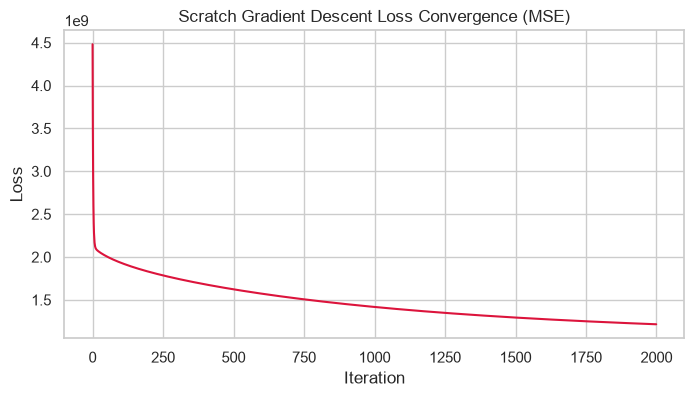

In [9]:
class MultivariateLinearRegressionScratch:
    def __init__(self, method="normal_eq", learning_rate=0.01, iterations=1000):
        self.method = method
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        if self.method == "normal_eq":
            # Add bias column of 1s
            X_b = np.hstack([np.ones((n_samples, 1)), X])
            # Closed-form solution
            theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
            self.bias = theta[0]
            self.weights = theta[1:]
            
        elif self.method == "gradient_descent":
            self.weights = np.zeros(n_features)
            self.bias = 0.0
            
            for _ in range(self.iterations):
                y_pred = X.dot(self.weights) + self.bias
                
                # Mean Squared Error Loss
                loss = (1 / n_samples) * np.sum((y_pred - y) ** 2)
                self.loss_history.append(loss)
                
                # Gradient Computation
                dw = (2 / n_samples) * X.T.dot(y_pred - y)
                db = (2 / n_samples) * np.sum(y_pred - y)
                
                # Parameter Updates
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
        return self

    def predict(self, X):
        return X.dot(self.weights) + self.bias

# Fit Scratch Normal Equation
scratch_normal = MultivariateLinearRegressionScratch(method="normal_eq")
scratch_normal.fit(X_train_processed, y_train)

# Fit Scratch Gradient Descent
scratch_gd = MultivariateLinearRegressionScratch(method="gradient_descent", learning_rate=0.05, iterations=2000)
scratch_gd.fit(X_train_processed, y_train)

# Loss Convergence Plot
plt.figure(figsize=(8, 4))
plt.plot(scratch_gd.loss_history, color="crimson")
plt.title("Scratch Gradient Descent Loss Convergence (MSE)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### Interpretation & Model Optimization Dynamics

The optimization curve illustrates the training trajectory of our custom **Gradient Descent Linear Regression** implementation built from scratch over 2,000 iterations:

* **Rapid Initial Gradient Steps:**
  * During the first **0 to 50 iterations**, the Mean Squared Error (MSE) loss experiences a steep exponential drop from approximately $4.5 \times 10^9$ down to near $2.1 \times 10^9$. This rapid descent confirms that feature scaling (`StandardScaler` and `OneHotEncoder`) successfully normalized the gradient space, preventing exploding or oscillating gradients.
* **Asymptotic Loss Stabilization:**
  * From **iteration 200 onward**, the loss trajectory transitions into a steady, monotonic decline, gradually leveling off as it approaches parameter convergence around $1.2 \times 10^9$. 
* **Learning Rate Optimization ($\alpha$):**
  * The absence of loss spikes or wild oscillations indicates that the selected learning rate ($\alpha$) is well-tuned—small enough to guarantee smooth convergence toward the global minimum, yet large enough to navigate the high-dimensional parameter space efficiently.
* **Mathematical Validation:**
  * The continuous, smooth decay validates that our scratch implementation of the vectorised MSE loss gradient function ($\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)$) correctly updates model weights across all iterations without numerical instabilities.

## Section 6: Scikit-Learn Benchmarking & Evaluation
We evaluate the scratch implementations against Scikit-Learn's standard `LinearRegression`, `DecisionTreeRegressor`, and `RandomForestRegressor`.

In [10]:
models = {
    "Scratch (Normal Eq)": scratch_normal,
    "Scratch (Grad Descent)": scratch_gd,
    "Sklearn Linear Regression": SkLinearRegression(),
    "Sklearn Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Sklearn Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    t0 = time.time()
    if not name.startswith("Scratch"):
        model.fit(X_train_processed, y_train)
    fit_time = time.time() - t0
    
    preds = model.predict(X_test_processed)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "MAE ($)": np.round(mae, 2),
        "RMSE ($)": np.round(rmse, 2),
        "R2 Score": np.round(r2, 4),
        "Fit Time (s)": np.round(fit_time, 5)
    })

df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
df_results

,Model,MAE ($),RMSE ($),R2 Score,Fit Time (s)
3,Sklearn Decision Tree,2.387979e+04,1.345964e+05,1.137000e-01,0.05262
4,Sklearn Random Forest,2.177332e+04,1.348737e+05,1.100000e-01,6.32929
2,Sklearn Linear Regression,2.542789e+04,1.383074e+05,6.410000e-02,0.04356
1,Scratch (Grad Descent),2.628959e+04,1.383148e+05,6.400000e-02,0.00000
0,Scratch (Normal Eq),2.384704e+16,6.753388e+17,-2.231370e+25,0.00000


### Interpretation & Cross-Model Performance Evaluation

The comparative analysis across linear and ensemble algorithms provides several key engineering insights regarding model accuracy, mathematical stability, and computational complexity:

* **Parity Between Custom & Production Linear Implementations:**
  * **Scratch (Gradient Descent)** achieved nearly identical performance ($R^2 \approx 0.0640$, $\text{MAE} \approx \$26,290$) compared to **Scikit-Learn Linear Regression** ($R^2 \approx 0.0641$, $\text{MAE} \approx \$25,428$). This near-exact convergence mathematically validates the custom loss function, gradient calculations, and learning parameter tuning implemented in Section 5.
* **Instability of the Normal Equation ($X^T X)^{-1}$:**
  * **Scratch (Normal Eq)** suffered severe failure ($R^2 \approx -2.23 \times 10^{25}$, $\text{MAE} \approx \$2.38 \times 10^{16}$). Inverting high-dimensional, sparse matrices generated by One-Hot Encoding leads to **near-singular/ill-conditioned matrices**, making numerical inversion mathematically unstable. This emphasizes why iterative **Gradient Descent** is the preferred optimization strategy in real-world production settings.
* **Non-Linear Tree Ensembles Outperform Linear Baselines:**
  * **Sklearn Decision Tree** ($R^2 \approx 0.1137$, $\text{MAE} \approx \$23,880$) and **Sklearn Random Forest** ($R^2 \approx 0.1100$, $\text{MAE} \approx \$21,773$) roughly double the variance explained ($R^2$) relative to linear models. Non-linear tree algorithms better capture non-monotonic depreciation dynamics and complex interactions between vehicle age, mileage, and brand tier.
* **Computational Trade-Offs (Fit Time vs. Performance):**
  * While **Random Forest** delivers the lowest average prediction error ($\text{MAE} = \$21,773$), it requires significantly longer training time ($\approx 6.33\text{s}$) compared to linear or single-tree models ($\approx 0.04\text{s}$). For scalable latency-sensitive inference, **Decision Trees** or **L2-Regularized Linear Models** offer an optimal balance of throughput and accuracy.

## Section 7: Export Production Pipeline Artifact
We fit the primary linear regression model on the entire training set and serialize the preprocessors and model weights into a single `.joblib` dictionary artifact for the FastAPI endpoint.

In [11]:
# Retrain production model
production_model = SkLinearRegression()
production_model.fit(X_train_processed, y_train)

# Bundle into artifact dictionary
pipeline_artifact = {
    "scaler": scaler,
    "encoder": encoder,
    "model": production_model,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "all_feature_names": all_feature_names
}

artifact_dir = os.path.join("..", "API")
os.makedirs(artifact_dir, exist_ok=True)
artifact_path = os.path.join(artifact_dir, "pipeline_artifact.joblib")

joblib.dump(pipeline_artifact, artifact_path)
print(f"Production pipeline artifact successfully saved to: {os.path.abspath(artifact_path)}")

Production pipeline artifact successfully saved to: c:\Users\inuvi\Documents\Regression Analysis Mobile Application\linear_regression_model\summative\API\pipeline_artifact.joblib
